In [45]:
import json
import random
import subprocess
import time
import itertools
import os
from collections import Counter
import pandas as pd
import shutil
from concurrent.futures import ThreadPoolExecutor, as_completed
from copy import deepcopy
import matplotlib.pyplot as plt
import pickle


## Read in Data and Clean

In [46]:
with open("oracle-cards-20260508090243.json", "r", encoding="utf-8") as file:
    FullCardList = json.load(file)

# remove add duplicates explained below ======================================================================
before = len(FullCardList)
print("Total Before Removal: ", before)

itemsRemoved = {}
illegal = []

for c in FullCardList[:]: # copy so we can delete and iterate at same time
    if "//" in c["name"]:
        parts=c["name"].split("//")
        if parts[0].strip() == parts[1].strip():
            itemsRemoved[c["name"]] = c.items()
            FullCardList.remove(c)

# remove non-legal standard cards ============================================================================
for c in FullCardList[:]:
    if ((c["legalities"]["standard"] == "not_legal") ):
        if c["name"] not in itemsRemoved:
            illegal.append(c["name"])
            FullCardList.remove(c)


print("number of items removed (//): ", len(itemsRemoved))
print("number of non-legal removed: ", len(illegal))

print("")
print("Total after removal: ", len(FullCardList))
print("Total number of items removed: ", before - (len(FullCardList)))

Total Before Removal:  37442
number of items removed (//):  2189
number of non-legal removed:  30810

Total after removal:  4440
Total number of items removed:  33002


In [47]:
#for items in itemsRemoved:
 #   print(items)
'''
-non-legal cards that should be removed, these are labelled as legal
listed as dual sided cards however base printings are single sided-
'''

'\n-non-legal cards that should be removed, these are labelled as legal\nlisted as dual sided cards however base printings are single sided-\n'

In [48]:
#for items in illegal:
 #   print(items)

In [49]:
'''
seeing what card elements to keep
following where seen as irrelevant
'''

removeElements = ["set_type",
                  "mtgo_id",
                  "tcgplayer_id",
                  "lang",
                  "released_at",
                  "uri",
                  "scryfall_uri",
                  "highres_image",
                  "image_status",
                  "image_uris",
                  "set_uri",
                  "set_search_uri",
                  "scryfall_set_uri",
                  "rulings_uri",
                  "prints_search_uri",
                  "watermark",
                  "artist",
                  "artist_ids",
                  "illustration_id",
                  "border_color",
                  "frame",
                  "frame_effects",
                  "security_stamp",
                  "full_art",
                  "testless",
                  "booster",
                  "story_spotlight",
                  "related_uris",
                  "purchase_uris",
                  "digital",
                  "foil",
                  "nonfoil",
                  "preview",
                  "games",
                  "finishes",
                  "oversized",
                  "promo",
                  "reprint",
                  "textless"]

for card in FullCardList:
    for key in removeElements:
        card.pop(key,None)
                  

In [50]:
cards = {card["name"]: card for card in FullCardList}

### List of all standard legal cards

In [51]:
cards = dict(sorted(cards.items()))
for key, value in cards.items():
    print(key, " :", value["type_line"])

A Killer Among Us  : Enchantment
A Realm Reborn  : Enchantment
A Tale for the Ages  : Enchantment
Aang's Iceberg  : Enchantment
Aang's Journey  : Sorcery — Lesson
Aang, Swift Savior // Aang and La, Ocean's Fury  : Legendary Creature — Human Avatar Ally // Legendary Creature — Avatar Spirit Ally
Aang, at the Crossroads // Aang, Destined Savior  : Legendary Creature — Human Avatar Ally // Legendary Creature — Avatar Ally
Aang, the Last Airbender  : Legendary Creature — Human Avatar Ally
Aatchik, Emerald Radian  : Legendary Creature — Insect Druid
Abandon Attachments  : Instant — Lesson
Abandoned Air Temple  : Land
Abandoned Campground  : Land
Aberrant Manawurm  : Creature — Wurm
Abhorrent Oculus  : Creature — Eye
Abigale, Eloquent First-Year  : Legendary Creature — Bird Bard
Abigale, Poet Laureate // Heroic Stanza  : Legendary Creature — Bird Bard // Sorcery
Abrade  : Instant
Abraded Bluffs  : Land — Desert
Absolute Virtue  : Legendary Creature — Avatar Warrior
Absolving Lammasu  : Creat

### Colour specific card lists

In [52]:
#
##
# here card lists are made for all mono colour and all dual colour cards lists, 
# the names chosen are the commonly used name by the community 
#
#
blackCards = {}
blueCards = {}
greenCards = {}
redCards = {}
whiteCards = {}

azoriousCards = {} #white blue 1
dimirCards = {} # blue black 2
rakdosCards = {} # black red 3
gruulCards = {} # red green 4
selesnyaCards = {} #green white 5

orzhovCards = {} # white black 6
golgariCards = {} #black green 7
simicCards = {} #green blue 8
izzetCards = {} #blue red 9
borosCards = {} #red white 10


multiColourCards = {}

for key, value in cards.items():

#all mono colour cards
    #print(value["color_identity"])
    if (set(value["color_identity"]).issubset(["B"]) ):
        #print(key)
        blackCards[key] = value

    if (set(value["color_identity"]).issubset(["U"]) ):
        blueCards[key] = value

    if (set(value["color_identity"]).issubset(["G"]) ):
        greenCards[key] = value

    if (set(value["color_identity"]).issubset(["R"]) ):
        redCards[key] = value

    if (set(value["color_identity"]).issubset(["W"])):
        whiteCards[key] = value
    

# many decks use more than on colour
# two colour combinations
    if (set(value["color_identity"]).issubset(["U","W"])): #1
        azoriousCards[key] = value

    if (set(value["color_identity"]).issubset(["B","U"])): #2
        dimirCards[key] = value

    if (set(value["color_identity"]).issubset(["B","R"])): #3
        rakdosCards[key] = value

    if (set(value["color_identity"]).issubset(["G","R"])): #4
        gruulCards[key] = value

    if (set(value["color_identity"]).issubset(["G","W"])): #5
        selesnyaCards[key] = value


    if (set(value["color_identity"]).issubset(["B","W"])): #6
        orzhovCards[key] = value

    if (set(value["color_identity"]).issubset(["B","G"])): #7
        golgariCards[key] = value

    if (set(value["color_identity"]).issubset(["U","G"])): #8
        simicCards[key] = value

    if (set(value["color_identity"]).issubset(["U","R"])): #9
        izzetCards[key] = value

    if (set(value["color_identity"]).issubset(["W","R"])): #10
        borosCards[key] = value


print("azorious Cards:    ", len(azoriousCards)) #1
print("dimir Cards:       ", len(dimirCards)) #2
print("rakdos Cards:      ", len(rakdosCards)) #3
print("gruul Cards:       ", len(gruulCards)) #4
print("selesnya Cards:    ", len(selesnyaCards)) #5
print("orzhov Cards:      ", len(orzhovCards)) #6
print("golgari Cards:     ", len(golgariCards)) #7
print("simic Cards:       ", len(simicCards)) #8
print("izzet Cards:       ", len(izzetCards)) #9
print("boros Cards:       ", len(borosCards)) #10


Alldicts = (blackCards, blueCards, greenCards, redCards ,whiteCards ,azoriousCards ,dimirCards ,rakdosCards, gruulCards, selesnyaCards, orzhovCards, golgariCards, simicCards,izzetCards ,borosCards )

azorious Cards:     1649
dimir Cards:        1655
rakdos Cards:       1668
gruul Cards:        1640
selesnya Cards:     1648
orzhov Cards:       1691
golgari Cards:      1680
simic Cards:        1655
izzet Cards:        1677
boros Cards:        1683


In [53]:
print(len(blackCards) )
print(len(whiteCards) )
print( len(greenCards) )
print( len(redCards) )
print(len(blueCards))
print(len(multiColourCards))

953
947
932
946
935
0


## Searching

### check if card name contains "(text)" 

In [85]:

search = "cloud"

for c in FullCardList:
    if search.lower() in c["name"].lower():
        print(c["name"])

Cloud, Midgar Mercenary
Tempest Hart // Scan the Clouds
Cloud of Darkness
Cloudspire Coordinator
Cloudsculpt Technician
Cloud, Planet's Champion
Oltec Cloud Guard
Shepherd of the Clouds
Cloudspire Captain
Cloudbound Moogle
Cloudspire Skycycle
Cloudblazer


### layout types

In [55]:
search = ""
layoutTypes = set()

for c in FullCardList:
    if search in c["name"]:
        layoutTypes.add(c["layout"])

print(layoutTypes)

{'meld', 'split', 'case', 'transform', 'prepare', 'adventure', 'class', 'saga', 'normal', 'modal_dfc'}


In [56]:
search = "//"
layoutTypes = set()

for c in FullCardList:
    if search in c["name"]:
        layoutTypes.add(c["layout"])

print(layoutTypes)

{'split', 'transform', 'prepare', 'adventure', 'normal', 'modal_dfc'}


### Land list

In [86]:
#lands

search = "Basic Land"
landcount = 0

for c in FullCardList:
    if search in c["type_line"]:
        print(c["type_line"])
        landcount +=1

In [58]:
landcount

6

### Specific search (name + layout)

In [59]:

search = "//"
search2 = "prepare"

for c in FullCardList:
    if search.lower() in c["name"].lower():
        if search2.lower() in c["layout"].lower():
            print(c["name"], " : ", c["layout"])
            

Adventurous Eater // Have a Bite  :  prepare
Maelstrom Artisan // Rocket Volley  :  prepare
Blazing Firesinger // Seething Song  :  prepare
Goblin Glasswright // Craft with Pride  :  prepare
Emeritus of Ideation // Ancestral Recall  :  prepare
Scathing Shadelock // Venomous Words  :  prepare
Abigale, Poet Laureate // Heroic Stanza  :  prepare
Vastlands Scavenger // Bind to Life  :  prepare
Scheming Silvertongue // Sign in Blood  :  prepare
Infirmary Healer // Stream of Life  :  prepare
Studious First-Year // Rampant Growth  :  prepare
Emeritus of Conflict // Lightning Bolt  :  prepare
Landscape Painter // Vibrant Idea  :  prepare
Honorbound Page // Forum's Favor  :  prepare
Grave Researcher // Reanimate  :  prepare
Tam, Observant Sequencer // Deep Sight  :  prepare
Skycoach Conductor // All Aboard  :  prepare
Leech Collector // Bloodletting  :  prepare
Emeritus of Woe // Demonic Tutor  :  prepare
Campus Composer // Aqueous Aria  :  prepare
Sanar, Unfinished Genius // Wild Idea  :  prep

### Specific Search (name + info)

In [88]:
search = "Cloud, Midgar Mercenary"
for key, value in cards[search].items():
    print(key, " : ", value)

object  :  card
id  :  2cf7e8a3-fad7-413d-b17c-7519a9cf5fb5
oracle_id  :  33d2584b-bf29-4c22-bd45-14ba2fb98c0e
multiverse_ids  :  []
resource_id  :  CEA1703877C0B2F6590A22E684BCB51A8C4D746C344DF9995E26A7B2AFEEA984
cardmarket_id  :  824125
name  :  Cloud, Midgar Mercenary
layout  :  normal
mana_cost  :  {W}{W}
cmc  :  2.0
type_line  :  Legendary Creature — Human Soldier Mercenary
oracle_text  :  When Cloud enters, search your library for an Equipment card, reveal it, put it into your hand, then shuffle.
As long as Cloud is equipped, if a triggered ability of Cloud or an Equipment attached to it triggers, that ability triggers an additional time.
power  :  2
toughness  :  1
colors  :  ['W']
color_identity  :  ['W']
keywords  :  []
legalities  :  {'standard': 'legal', 'future': 'legal', 'historic': 'legal', 'timeless': 'legal', 'gladiator': 'legal', 'pioneer': 'legal', 'modern': 'legal', 'legacy': 'legal', 'pauper': 'not_legal', 'vintage': 'legal', 'penny': 'not_legal', 'commander': 'lega

In [61]:
search = "Plains"

for key, value in cards[search].items():
    print(key, " : ", value)

object  :  card
id  :  24dc369c-020a-4115-a4bb-d60a44de64e3
oracle_id  :  bc71ebf6-2056-41f7-be35-b2e5c34afa99
multiverse_ids  :  []
name  :  Plains
layout  :  normal
mana_cost  :  
cmc  :  0.0
type_line  :  Basic Land — Plains
oracle_text  :  ({T}: Add {W}.)
colors  :  []
color_identity  :  ['W']
keywords  :  []
produced_mana  :  ['W']
legalities  :  {'standard': 'legal', 'future': 'legal', 'historic': 'legal', 'timeless': 'legal', 'gladiator': 'legal', 'pioneer': 'legal', 'modern': 'legal', 'legacy': 'legal', 'pauper': 'legal', 'vintage': 'legal', 'penny': 'legal', 'commander': 'legal', 'oathbreaker': 'legal', 'standardbrawl': 'legal', 'brawl': 'legal', 'alchemy': 'legal', 'paupercommander': 'legal', 'duel': 'legal', 'oldschool': 'not_legal', 'premodern': 'legal', 'predh': 'legal', 'tlr': 'legal'}
reserved  :  False
game_changer  :  False
variation  :  False
set_id  :  59218c23-cb7a-4fde-9cff-3f2f71af1308
set  :  hob
set_name  :  The Hobbit
collector_number  :  194
rarity  :  common


### Specific search (typeline)

In [62]:
search = "basic"

for c in FullCardList:
    if search.lower() in c["type_line"].lower():
        print(c["name"] , " : ", c["type_line"])

Wastes  :  Basic Land
Swamp  :  Basic Land — Swamp
Mountain  :  Basic Land — Mountain
Island  :  Basic Land — Island
Forest  :  Basic Land — Forest
Plains  :  Basic Land — Plains


### Prices

In [106]:

countAbove1 = 0
countAbove5 = 0
countAbove10 = 0

for c in FullCardList:
    write = c["name"] + " : "
    if c["prices"]["eur"] is not None:
        write = write + c["prices"]["eur"]

        if(float(c["prices"]["eur"]) > 1):
            countAbove1 += 1
        if(float(c["prices"]["eur"]) > 5):
            countAbove5 += 1
        if(float(c["prices"]["eur"]) > 10):
            countAbove10 += 1
    else:
        write = write + "0"
    print(write)

    #print(write)


Greta, Sweettooth Scourge : 0.12
Seedship Agrarian : 0.16
South Wind Avatar : 1.04
Escape Tunnel : 0.13
Food Fight : 0.14
Witch's Mark : 0.13
Spider-Ham, Peter Porker : 0.36
Fear of Falling : 0.08
Solemn Simulacrum : 0.16
Stormchaser's Talent : 8.52
End-Blaze Epiphany : 0.11
Coeurl : 0.02
Oracle's Restoration : 0.05
Stand Up for Yourself : 0.05
Sagu Pummeler : 0.04
Unscrupulous Contractor : 0.07
Bogwater Lumaret : 0.08
Sanguine Indulgence : 0.17
Unfortunate Accident : 0.07
Strategic Betrayal : 0.49
Humbling Elder : 0.11
Mocking Sprite : 0
Doubling Season : 19.33
Kykar, Zephyr Awakener : 0.21
Quilled Greatwurm : 3.96
Hurl into History : 0.05
Don & Raph, Hard Science : 0.21
Memory Vessel : 0.27
Optimistic Scavenger : 0.19
Nimble Thopterist : 0.08
Fear of Infinity : 0.14
Bloodthorn Flail : 0.13
Snow Villiers : 0.14
Airship Engine Room : 0.07
Illegitimate Business : 0.14
Reasonable Doubt : 0.06
Flashback : 4.28
Taster of Wares : 0.07
Beza, the Bounding Spring : 8.28
Adventurous Eater // Ha

In [107]:

print(countAbove1)
print(countAbove5)
print(countAbove10)

543
173
78


## Functions

In [63]:
##
# cards is the dictionary working with
# cards and their info
#

print("   \"cards\" is a dictionary of dictionaries")
print("Type of \"cards\"                          :", type(cards))
print("Types of items in \"cards\"                :", type(cards["Plains"]))
print("length of \"cards\"                        :", len(cards))
print("")

print("   \"FullCardList\" is a List of dictionaries")
print("Type of \"FullCardList\"                   :", type(FullCardList))
print("Types of items in \"FullCardList\"         :", type(FullCardList[1]))
print("length of \"FullCardList\"                 :", len(cards))

   "cards" is a dictionary of dictionaries
Type of "cards"                          : <class 'dict'>
Types of items in "cards"                : <class 'dict'>
length of "cards"                        : 4440

   "FullCardList" is a List of dictionaries
Type of "FullCardList"                   : <class 'list'>
Types of items in "FullCardList"         : <class 'dict'>
length of "FullCardList"                 : 4440


### Writing to File

In [64]:
'''
make sure all cards have a name
set
and collector number
'''


def writeToFile(name, cardList, decklist, verbose=False):

    path = r"C:\Users\liam1\AppData\Roaming\Forge\decks\constructed" + "\\" + name + ".dck"

    with open(path, "w", encoding="utf-8") as file:
        file.write("[metadata]\n")
        file.write("Name=" + name + "\n")
        file.write("[Main]\n")

        for name in decklist:

            if( (cardList[name]["layout"] == "normal") or 
               (cardList[name]["layout"] == "saga") or 
               (cardList[name]["layout"] == "split") or
               (cardList[name]["layout"] == "meld") or
               (cardList[name]["layout"] == "class") ):
                write = "1 " + name + "|" + cardList[name]["set"] + "|" + cardList[name]["collector_number"] + "\n"
                file.write(write)

            elif( (cardList[name]["layout"] == "transform") or 
                 (cardList[name]["layout"] == "flip") or 
                 (cardList[name]["layout"] == "prepare") or
                 (cardList[name]["layout"] == "adventure") or
                 (cardList[name]["layout"] == "modal_dfc") ):
                parts = name.split("//")
                write = "1 " + parts[0].strip() + "|" + cardList[name]["set"] + "|" + cardList[name]["collector_number"] + "\n"
                file.write(write)

            if verbose:
                print(write)
            

### Check Legality

In [65]:
## put in main loop
def isLegal(length, cardlist, decklist):
    if len(decklist) != length:
        return False

    for name, count in Counter(decklist).items():

        if "basic land" in cardlist[name]["type_line"].lower():
            continue
        if count > 4:
            return False

    return True

### Evaluate Deck

In [66]:

def evalDeck(name, cardList, deckList, verbose = False):
    print(f"deck {name} STARTED")
    score = 0

    # write to .dck file
    writeToFile(name, cardList, deckList, verbose)

    forgePath = r"C:\Users\liam1\AppData\Roaming\Forge\decks\constructed"
    themeDecks = ["Lifegain", "Blink", "Waggro", "Selesnya", "Izzet"] # "Pirates", "Angels", "Eerie" ,  
    #play agisnt decks
    for i in themeDecks:

        try:
        
            result = subprocess.run(
                [
                    "java", "-Xmx1g", "-Xms1g",
                    "-jar", r"C:\Users\liam1\Desktop\Forge\forge-gui-desktop-2.0.12-jar-with-dependencies.jar",
                    "sim",
                    "-d", i, name,
                    "-n", "1",
                    "-q"
                ],
                capture_output = True,
                text = True,
                cwd = r"C:\Users\liam1\Desktop\Forge",
                timeout = 120
            
            )

            output = result.stdout.strip().split("\n")
            results = output[-1:]
            if verbose:
                print(results[0])
        #print(result.stdout)

            if i in results[0]: # this shows output the deck that won
                continue # if theme deck won proceed
            else: # else add 1 to score
                score +=1
        except subprocess.TimeoutExpired:
            continue
    
    #get results
    print(f"deck {name} FINISHED")
    return name, score

### Fitness Functions

In [67]:
##
#
# 
#
def fitness(population, cardsList):
    ## first copy over the testing base line decks into the correct directory
    #they must be here for games to be played
    #i clear the directory later to ensure no past decks overwrite current ones
    deckStoreDir = r"C:\Users\liam1\Desktop\finalYearProject\decklists"
    forgeDir = r"C:\Users\liam1\AppData\Roaming\Forge\decks\constructed"
    
    #for file in os.listdir(deckStoreDir):
     #   if file.endswith(".dck"):
      #      shutil.copy(os.path.join(deckStoreDir, file), forgeDir)


    with ThreadPoolExecutor(max_workers = 5 ) as executor:
        f = {executor.submit(evalDeck, str(i), cardsList, m[0] , False): m
             for i, m in enumerate(population)
            }

        for fr in as_completed(f):
            i, score = fr.result()
            population[int(i)][1] = score
            
            
    ## CLEAR DIR SO THIER CAN'T BE ANY INCORRECT READINGS
    #for file in os.listdir(forgeDir):
     #   if file.endswith(".dck"):
      #      os.remove(os.path.join(forgeDir,file))
    
    return population


### Generate Random Decks

In [68]:

##
# this will generate a random decklist one card at atime allowing cards to be added multiple times
#
#

def randDeck(cardlist, deckSize, verbose=False):
    rOutput = []
    for n in range(deckSize):
        selectR = random.sample(list(cardlist.keys()), 1)
        count = rOutput.count(selectR)

        if "basic land" in cardlist[selectR[0]]["type_line"].lower():
            rOutput.append(selectR[0])

        elif count < 4:
            rOutput.append(selectR[0])

    if verbose:
        print(rOutput)
        print( len(rOutput))
    return rOutput

    
##
# card games heavily lean towards containing multiples of cards so next random generation method willatt 2 of each card  
#
#
def randDeck2(cardlist, deckSize, verbose = False):
    rOutput = []
    for n in range(deckSize // 2):
        selectR = random.sample(list(cardlist.keys()), 1)
        count = rOutput.count(selectR)

        if "basic land" in cardlist[selectR[0]]["type_line"].lower():
            rOutput.append(selectR[0])
            rOutput.append(selectR[0])

        elif count < 4:
            rOutput.append(selectR[0])
            rOutput.append(selectR[0])
            
    if verbose:
        print(rOutput)
        print( len(rOutput))
    return rOutput  

##
#
#
#
def randDeckMulti(cardlist, deckSize, verbose = False):
    rOutput = []
    size = 0
    while size < deckSize:
        selectR = random.sample(list(cardlist.keys()), 1)
        count = rOutput.count(selectR)

        numCopies = random.randint(1,4)

        numCopies = numCopies - count

        for n in range(numCopies):
            if "basic land" in cardlist[selectR[0]]["type_line"].lower():
                rOutput.append(selectR[0])

            elif count < 4:
                rOutput.append(selectR[0])

        size = len(rOutput)

    rOutput = rOutput[:deckSize]

    if verbose:
        print(rOutput)
        print( len(rOutput))
    return rOutput
            

In [69]:
##
# this funciton guarantees basic lands are added
# calls the init operates and then adds basic lands based on thier colour
#
def genWL(cardlist, decksize, verbose = False):

    deckWOLands = decksize - 16

    deck = randDeck(cardlist, deckWOLands, verbose)

    colours = set()

    for c in deck:
        for col in cardlist[c]["color_identity"]:
            colours.add(col)

    while len(deck) < 60:
        #print(len(deck))
        for c in colours:
            if c == "W":
                deck.append("Plains")
            if c == "U":
                deck.append("Island")
            if c == "B":
                deck.append("Swamp")
            if c == "R":
                deck.append("Forest")
            if c == "G":
                deck.append("Mountain")
            
    deck = deck[:decksize]
    if verbose:
        print(colours)
        print(len(deck))
            
    return deck

##
# this funciton guarantees basic lands are added
# calls the init operates and then adds basic lands based on thier colour
# same as above but uses randDeck2
#
def genWL2(cardlist, decksize, verbose = False):

    deckWOLands = decksize - 16

    deck = randDeck2(cardlist, deckWOLands, verbose)

    colours = set()

    for c in deck:
        for col in cardlist[c]["color_identity"]:
            colours.add(col)

    while len(deck) < 60:
        #print(len(deck))
        for c in colours:
            if c == "W":
                deck.append("Plains")
            if c == "U":
                deck.append("Island")
            if c == "B":
                deck.append("Swamp")
            if c == "R":
                deck.append("Forest")
            if c == "G":
                deck.append("Mountain")
            
    deck = deck[:decksize]
    if verbose:
        print(colours)
        print(len(deck))
            
    return deck

##
# this funciton guarantees basic lands are added
# calls the init operates and then adds basic lands based on thier colour
# same as above but uses randDeck2
#
def genWLMulti(cardlist, decksize, verbose = False):

    deckWOLands = decksize - 16

    deck = randDeckMulti(cardlist, deckWOLands, verbose)

    colours = set()

    for c in deck:
        for col in cardlist[c]["color_identity"]:
            colours.add(col)

    while len(deck) < 60:
        #print(len(deck))
        for c in colours:
            if c == "W":
                deck.append("Plains")
            if c == "U":
                deck.append("Island")
            if c == "B":
                deck.append("Swamp")
            if c == "R":
                deck.append("Forest")
            if c == "G":
                deck.append("Mountain")
            
    deck = deck[:decksize]
    if verbose:
        print(colours)
        print(len(deck))
            
    return deck


### Crossover

In [70]:
def crossoverPositonal(deck1, deck2, verbose= False):
    if len(deck1) != len(deck2):
        print("diff len")
        print(len(deck1))
        print(len(deck2))
        print("")
        return None
    
    newDeck =[]
    for n in range(len(deck1)):
        temp = random.sample([deck1[n],deck2[n]], 1)
        newDeck.append(temp[0])

    if verbose:
        print(newDeck)
        print( len(newDeck))
    return newDeck

def crossoverPoint(deck1, deck2, verbose= False):
    if len(deck1) != len(deck2):
        print("diff len")
        print(len(deck1))
        print(len(deck2))
        print("")
        return None

    
    point = random.randint(1, len(deck1) -1)
    newDeck = deck1[:point] + deck2[point:]
    if verbose:
        print(newDeck)
        print( len(newDeck))
    return newDeck

### Mutation

In [71]:
##
# goes through every spot in the deck and with mutaterate probablity it mutates it into a random card
#
#

def mutateSpot(deck, cardlist, mutateRate, verbose=True):
    newDeck = deck[:]

    for n in range(len(deck)):
        if random.random() < mutateRate:
            selectR = random.sample(list(cardlist.keys()), 1)
            while(selectR[0] in deck or selectR[0] in newDeck):
                selectR = random.sample(list(cardlist.keys()), 1)
            newDeck[n] = selectR[0]

    if verbose:
        print(newDeck)
        print( len(newDeck))
    return newDeck
    
##
# 
#
#
def mutateCard(deck, cardlist, mutateRate, verbose=True):
    tempDeck = deck[:]
    arr = set(deck)
    for card in arr:
        if "basic land" in cardlist[card]["type_line"].lower():
            continue
        if random.random() < mutateRate:
            selectR = random.sample(list(cardlist.keys()), 1)
            while(selectR[0] in deck or selectR[0] in tempDeck):
                selectR = random.sample(list(cardlist.keys()), 1)

            tempDeck =  [x for x in tempDeck if x !=card]
            for n in range(len(deck) - len(tempDeck)):
                tempDeck.append(selectR[0])

        newDeck = tempDeck[:len(deck)]

    if verbose:
        print(newDeck)
        print( len(newDeck))
    return newDeck


##
#
#
#
def mutateCopy(deck, cardlist, mutateRate, verbose=True):
    newDeck = deck[:]
    for i, card in enumerate(newDeck):
        if random.random() < mutateRate:
            selectR = random.choice(deck)
            if (newDeck.count(selectR) < 4):
                newDeck[i] = selectR
    if verbose:
        print(newDeck)
        print( len(newDeck))
    return newDeck

### Main Body Funciton

In [72]:
##
# populaiton is a list of lists which contain a list (the deck) and a score (fitness)
# [
#  [deck, score]
# ]
# deck = [mountain, plains, ....]
#
def mainGeneticAlgo(
    #fitness Funciton
    # inputs fitness(population, cardsList):
        f,
    #check legality function
    #inputs (length, cardlist, decklist)
        isLegal,
    
    #init function
    #inputs = (cardlist, deckSize, verbose=False)
        init,
    #crossover
    # inputs = (deck1, deck2, verbose= False)
        crossover,
    #mutate
    #inputs = (deck, cardlist, mutateRate, verbose=True):
        mutate,

    #card list
        cardsList,
    #population size
        popSize = 16,
    #number of generations
        generations = 100,
    #deck size
        deckSize = 60,
    #mutateRate
        mutateRate=0.3,

    #verbose
        verbose = False
):
#=========================================================
    currentgen = 0
    going = True

    bestScores = []
    avgScores = []

    topPreformers = []

    ##init --------------------------------------
    population = []
    while len(population) < popSize:
        createGoing = True
        while(createGoing):
            temp = init(cardsList, deckSize, False)

            if isLegal(deckSize, cardsList, temp):
                createGoing = False
        population.append([temp,0])

    
    while(going):
        
        print("")
        print("current gen: ", currentgen)
        
        tempPop = []
        parents = []

    ##fitness
        population = f(population, cardsList)

        population.sort(key=lambda x: x[1], reverse=True)

    ##storing
        if (currentgen == 0):
            firstPop = deepcopy(population)

        else:
            prevPop = deepcopy(population)

    ##graphing
        scores = [i[1] for i in population]
        bestScores.append(max(scores))
        avgScores.append( sum(scores)/len(scores) )

        topPreformers.append([population[0][0], population[0][1]])

        with open("checkpoint.pkl", "wb") as file:
            pickle.dump({
                "gen": currentgen,
                "population": population,
                "bestScores": bestScores,
                "avgScores": avgScores,
                "topPreformers": topPreformers,
            }, file)

    ##selection top 1 guaranteed survival
        
        tempPop.append([population[0][0], 0])

    
        while( len(tempPop) < popSize-2 ):
            legal = False

            mChild = []
            
            # only add legal decks
            while not legal:

    ##selection (parents)
                p1, p2 = random.choices(
                    population,
                    weights = [score for _, score in population],
                    k=2
                )
                while p1 is p2:
                    p2 = random.choices(
                        population,
                        weights = [score for _, score in population],
                        k=1
                    )[0]
    ##crossover
                #
                child = crossover(p1[0], p2[0], verbose)

                if (child == None):
                    continue
            
    ##mutation
                #
                mChild = mutate(child, cardsList, mutateRate, verbose)
                if (mChild == None):
                    continue

    ##check legality
                #
                legal = isLegal(deckSize, cardsList, mChild)
                
            tempPop.append([mChild, 0])
            
        population = tempPop
            

    ##add some more randomness add 2 random

        while len(population) < popSize:
            createGoing = True
            while(createGoing):
                temp = init(cardsList, deckSize, False)

                if isLegal(deckSize, cardsList, temp):
                    createGoing = False
            population.append([temp,0])

        currentgen +=1
        
        if(currentgen > generations):
            going = False

        if len(topPreformers) >= 5:  # if the top deck is the same 5 times in a row
            last5Stop = [t[0] for t in topPreformers[-5:]]
            if all(x == last5Stop[0] for x in last5Stop): 
                going = False
                
        if len(topPreformers) >= 3:
            last3Stop = [t[0] for t in topPreformers[-3:]]
            if all(x == last3Stop[0] for x in last3Stop): # if the same top deck gets max points 3 times in a row
                last3StopScores = [t[1] for t in topPreformers[-3:]]
                if all(x == 5 for x in last3StopScores):
                    going = False

    return population, firstPop, prevPop, bestScores, avgScores

### 2nd main body function

In [110]:
##
## help for mitigating laptop shut downs and crashes
# read in data from file
# determine if I should continue to run or no
# proceed from last checkpoint


def mainGeneticAlgo2(
        #fitness Funciton
    # inputs fitness(population, cardsList):
        f,
    #check legality function
    #inputs (length, cardlist, decklist)
        isLegal,
    
    #init function
    #inputs = (cardlist, deckSize, verbose=False)
        init,
    #crossover
    # inputs = (deck1, deck2, verbose= False)
        crossover,
    #mutate
    #inputs = (deck, cardlist, mutateRate, verbose=True):
        mutate,

    #card list
        cardsList,
    #population size
        popSize = 10,
    #number of generations
        generations = 50,
    #deck size
        deckSize = 60,
    #mutateRate
        mutateRate=0.3,

    #verbose
        verbose = False
):
#=========================================================
    path = "checkpoint.pkl"
    if os.path.exists(path):
        with open(path, "rb") as file:
            checkpoint = pickle.load(file)

        currentgen =  checkpoint["gen"]
        population = checkpoint["population"]
        bestScores = checkpoint["bestScores"]
        avgScores = checkpoint["avgScores"]
        topPreformers = checkpoint["topPreformers"]

        print(currentgen)
        print("")
        print(bestScores)
        print("")
        print(avgScores)
        print("")
        print(topPreformers)
        print("")
        print(population)

        return topPreformers[0],0,0,0,0

    else:
        return 0, 0,0,0, 0

In [111]:
start = time.time()
out, firstPop, prevPop, bestScores, avgScores = mainGeneticAlgo2(
    #fitness Funciton
    # inputs fitness(population, cardsList):
        fitness,
    #check legality function
    #inputs (length, cardlist, decklist)
        isLegal,    
    #init function
    #inputs = (cardlist, deckSize, verbose=False)
        genWLMulti,
    #crossover
    # inputs = (deck1, deck2, verbose= False)
        crossoverPositonal,
    #mutate
    #inputs = (deck, cardlist, mutateRate, verbose=True):
        mutateCard,
    #card list
        whiteCards,
    #population size
        popSize = 15,
    #number of generations
        generations = 100,
    #deck size
        deckSize = 60,
    #mutateRate
        mutateRate=0.3,
    #verbose
        verbose = False
)
print("")
print(f"{time.time() -start:.2f}s")

27

[5, 3, 2, 3, 4, 3, 3, 2, 3, 2, 2, 3, 4, 3, 2, 3, 3, 3, 5, 4, 4, 3, 3, 3, 2, 3, 4, 4]

[1.0666666666666667, 1.0666666666666667, 0.8, 1.2, 1.3333333333333333, 1.3333333333333333, 0.7333333333333333, 1.0, 1.3333333333333333, 1.1333333333333333, 1.0666666666666667, 1.2, 1.3333333333333333, 1.2, 1.2, 1.5333333333333334, 1.0666666666666667, 1.2, 2.0, 1.5333333333333334, 1.6, 1.4666666666666666, 1.4, 1.4666666666666666, 1.4, 1.4, 1.7333333333333334, 1.6]

[[['Reluctant Role Model', 'Reluctant Role Model', 'Reluctant Role Model', 'Regal Caracal', 'Regal Caracal', 'Regal Caracal', 'Star Charter', 'Star Charter', 'Star Charter', 'Star Charter', 'Avishkar Raceway', 'Avishkar Raceway', 'Avishkar Raceway', 'Avishkar Raceway', 'Contested Game Ball', 'Doorkeeper Thrull', 'Doorkeeper Thrull', 'Jolly Gerbils', 'Jolly Gerbils', 'Dauntless Veteran', 'Dauntless Veteran', 'Dauntless Veteran', 'Dalkovan Packbeasts', 'Scrap Compactor', 'Scrap Compactor', "Ajani's Response", "Ajani's Response", 'Phoenix D

In [113]:
out[0]

['Reluctant Role Model',
 'Reluctant Role Model',
 'Reluctant Role Model',
 'Regal Caracal',
 'Regal Caracal',
 'Regal Caracal',
 'Star Charter',
 'Star Charter',
 'Star Charter',
 'Star Charter',
 'Avishkar Raceway',
 'Avishkar Raceway',
 'Avishkar Raceway',
 'Avishkar Raceway',
 'Contested Game Ball',
 'Doorkeeper Thrull',
 'Doorkeeper Thrull',
 'Jolly Gerbils',
 'Jolly Gerbils',
 'Dauntless Veteran',
 'Dauntless Veteran',
 'Dauntless Veteran',
 'Dalkovan Packbeasts',
 'Scrap Compactor',
 'Scrap Compactor',
 "Ajani's Response",
 "Ajani's Response",
 'Phoenix Down',
 'Disruptor Wanderglyph',
 'Vanguard Seraph',
 'Vanguard Seraph',
 'Vanguard Seraph',
 'Sidequest: Catch a Fish // Cooking Campsite',
 'Sidequest: Catch a Fish // Cooking Campsite',
 'Prosperity Tycoon',
 'Voyager Glidecar',
 'Voyager Glidecar',
 'Voyager Glidecar',
 'Voyager Glidecar',
 'Barrels of Blasting Jelly',
 'Barrels of Blasting Jelly',
 'Barrels of Blasting Jelly',
 'Barrels of Blasting Jelly',
 'Mentor of the Me

In [118]:
testprice = 0
for c in out[0]:
     if cards[c]["prices"]["eur"] is not None:
         testprice += float(cards[c]["prices"]["eur"])


print(testprice)

10.350000000000001


In [76]:
with open("checkpoint.pkl", "rb") as file:
    data = pickle.load(file)

print(data["gen"])
print(data["bestScores"])
print(data["topPreformers"])

27
[5, 3, 2, 3, 4, 3, 3, 2, 3, 2, 2, 3, 4, 3, 2, 3, 3, 3, 5, 4, 4, 3, 3, 3, 2, 3, 4, 4]
[[['Reluctant Role Model', 'Reluctant Role Model', 'Reluctant Role Model', 'Regal Caracal', 'Regal Caracal', 'Regal Caracal', 'Star Charter', 'Star Charter', 'Star Charter', 'Star Charter', 'Avishkar Raceway', 'Avishkar Raceway', 'Avishkar Raceway', 'Avishkar Raceway', 'Contested Game Ball', 'Doorkeeper Thrull', 'Doorkeeper Thrull', 'Jolly Gerbils', 'Jolly Gerbils', 'Dauntless Veteran', 'Dauntless Veteran', 'Dauntless Veteran', 'Dalkovan Packbeasts', 'Scrap Compactor', 'Scrap Compactor', "Ajani's Response", "Ajani's Response", 'Phoenix Down', 'Disruptor Wanderglyph', 'Vanguard Seraph', 'Vanguard Seraph', 'Vanguard Seraph', 'Sidequest: Catch a Fish // Cooking Campsite', 'Sidequest: Catch a Fish // Cooking Campsite', 'Prosperity Tycoon', 'Voyager Glidecar', 'Voyager Glidecar', 'Voyager Glidecar', 'Voyager Glidecar', 'Barrels of Blasting Jelly', 'Barrels of Blasting Jelly', 'Barrels of Blasting Jelly',

In [77]:
## rough work

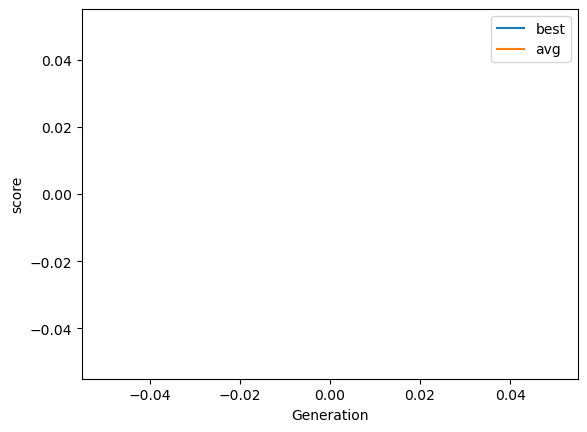

In [78]:

plt.plot(bestScores, label="best")
plt.plot(avgScores, label= "avg")
plt.xlabel("Generation")
plt.ylabel("score")
plt.legend()
plt.show()